TASK 1: MCP NEURON
AND Gate Implementation

AND Gate Implementation

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    MCP Neuron for AND Gate
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise sum
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        # Apply threshold
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example Usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result)

AND Output: [0, 0, 0, 1]


OR Gate Implementation

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    MCP Neuron for OR Gate
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example Usage
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


Limitations of MCP Neuron



-Cannot learn from data (no learning algorithm)

-Fixed weights and threshold

-Cannot solve non-linear problems (like XOR)

-No adaptability

-Works only for simple logical operations

XOR using MCP?

Not possible with single MCP neuron

 Reason:

-XOR is non-linearly separable

-MCP neuron is linear

TASK 2: PERCEPTRON (0 vs 1)

 Data Loading

In [ ]:
import pandas as pd
import numpy as np

df_0_1 = pd.read_csv("mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (12665, 784)
Label shape: (12665,)


Q1:
-X shape = (samples, features)

-Example: (1000, 784) → 1000 images, 784 pixels each

 Q2:
-y shape = number of labels (targets)

Visualize Dataset


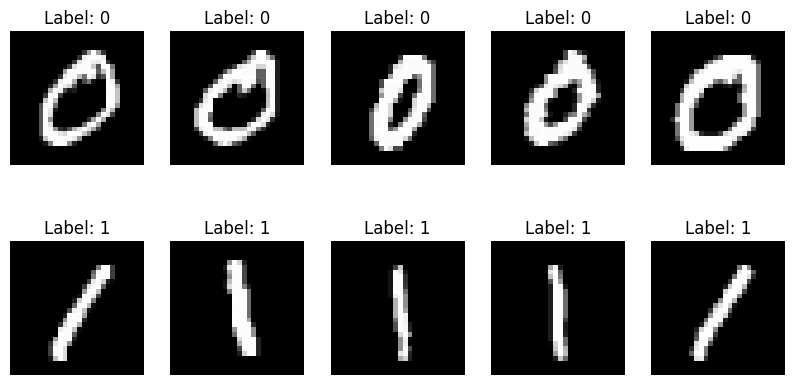

In [ ]:
import matplotlib.pyplot as plt

images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.show()

Initialize Weights

In [ ]:
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

Q3:
-weights represent importance of each pixel

 Q4:
-Initialized to zero for simplicity
-May slow learning but works for perceptron

Activation Function

Decision Function

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias

    # Step function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

Perceptron Training Algorithm

Training Function

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias

            # Prediction
            y_pred = 1 if output >= 0 else 0

            # Update if wrong
            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        accuracy = correct / len(X)

    return weights, bias, accuracy

 Q5:

-Computes weighted sum of inputs

 Q6:

-If wrong:

-weights updated

-bias updated

Q7:

-Accuracy shows performance

-Expected: close to 1 (100%) for 0 vs 1

Training Model

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


Misclassified Images

In [ ]:
import matplotlib.pyplot as plt

predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print("Final Accuracy:", final_accuracy)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0
All images were correctly classified!


Q8:

-Stores indices of wrong predictions

Q9:

-Model achieved perfect classification

PERCEPTRON (3 vs 5)

Load Dataset

In [ ]:
df = pd.read_csv("mnist_3_and_5.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

Reuse Training

In [ ]:
weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy (3 vs 5):", accuracy)

Final Accuracy (3 vs 5): 0.0


Misclassified Images

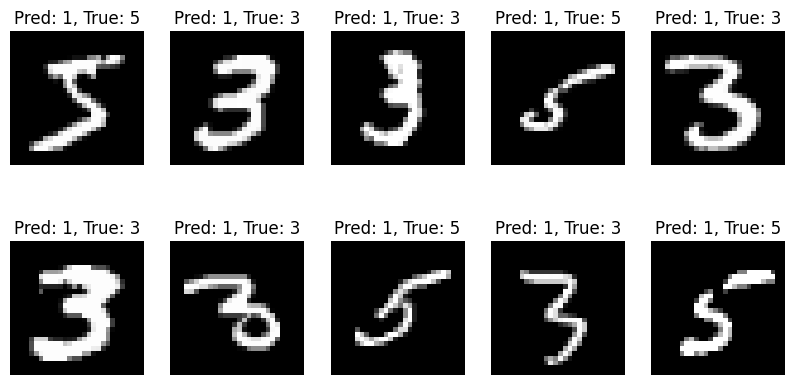

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()